<a href="https://colab.research.google.com/github/shashithenuwara/IOT/blob/main/MLmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install firebase-admin pandas

In [5]:
from google.colab import files
uploaded = files.upload()

Saving iotdba-firebase-adminsdk-fbsvc-9b342554a8.json to iotdba-firebase-adminsdk-fbsvc-9b342554a8.json


In [6]:
import firebase_admin
from firebase_admin import credentials, db
import pandas as pd

# Path to your downloaded service account file
SERVICE_ACCOUNT_FILE = "iotdba-firebase-adminsdk-fbsvc-9b342554a8.json"

# Your Firebase Realtime Database URL
DATABASE_URL = "https://iotdba-default-rtdb.firebaseio.com/"

# Initialize only once
if not firebase_admin._apps:
    cred = credentials.Certificate(SERVICE_ACCOUNT_FILE)
    firebase_admin.initialize_app(cred, {
        "databaseURL": DATABASE_URL
    })

# Example: read from a node called 'sensor_data'
ref = db.reference("/logs")
data = ref.get()

print(type(data))
print(data)

<class 'dict'>
{'-Oqk0awQcHb_miuPnopu': {'air_quality_ppm': 176.5871, 'date': '2026-04-21', 'humidity': 75.6, 'light': 0.833333, 'status': 'CRITICAL', 'temperature': 29.4375, 'time': '18:01:43', 'timestamp': '2026-04-21 18:01:43'}, '-Oqk0eiMekEmU_mr2i2B': {'air_quality_ppm': 174.7966, 'date': '2026-04-21', 'humidity': 75.2, 'light': 0.833333, 'status': 'CRITICAL', 'temperature': 29.4375, 'time': '18:01:57', 'timestamp': '2026-04-21 18:01:57'}, '-Oqk1-ebRgI2Jcc2er0k': {'air_quality_ppm': 170.3727, 'date': '2026-04-21', 'humidity': 74.5, 'light': 0.833333, 'status': 'CRITICAL', 'temperature': 29.4375, 'time': '18:03:28', 'timestamp': '2026-04-21 18:03:28'}, '-Oqk132q5e3Wgsl0-306': {'air_quality_ppm': 172.1333, 'date': '2026-04-21', 'humidity': 74.4, 'light': 0.833333, 'status': 'CRITICAL', 'temperature': 29.375, 'time': '18:03:42', 'timestamp': '2026-04-21 18:03:42'}, '-Oqk16TBEYzhXoFLYdK2': {'air_quality_ppm': 159.2145, 'date': '2026-04-21', 'humidity': 74.4, 'light': 133.3333, 'status'

In [7]:
df = pd.DataFrame.from_dict(data, orient="index")
df.head(40)
df.shape

(12884, 8)

In [8]:
#Ensure columns are numeric
df["temperature"] = pd.to_numeric(df["temperature"], errors="coerce")
df["humidity"] = pd.to_numeric(df["humidity"], errors="coerce")
df["light"] = pd.to_numeric(df["light"], errors="coerce")
df["air_quality_ppm"] = pd.to_numeric(df["air_quality_ppm"], errors="coerce")

In [9]:
#Drop Null vals
df = df.dropna()
df.shape

(12884, 8)

In [10]:
#Naming the first column
df = pd.DataFrame.from_dict(data, orient="index").reset_index().rename(columns={"index": "record_id"})

In [11]:
#Feature Engineering - Add new column
df["temp_critical"] = (df["temperature"] >= 30).astype(int)
df["hum_critical"] = (df["humidity"] >= 65).astype(int)
df["light_critical"] = (df["light"] >= 300).astype(int)
df["air_critical"] = (df["air_quality_ppm"] >= 1000).astype(int)
def get_critical_feature(row):
    critical = []

    if row["temp_critical"] == 1:
        critical.append("temperature")
    if row["hum_critical"] == 1:
        critical.append("humidity")
    if row["light_critical"] == 1:
        critical.append("light")
    if row["air_critical"] == 1:
        critical.append("air_quality_ppm")

    return ",".join(critical) if critical else "normal"

df["critical_feature"] = df.apply(get_critical_feature, axis=1)
df.head(40)

,record_id,air_quality_ppm,date,humidity,light,status,temperature,time,timestamp,temp_critical,hum_critical,light_critical,air_critical,critical_feature
0,-Oqk0awQcHb_miuPnopu,176.5871,2026-04-21,75.6,0.833333,CRITICAL,29.4375,18:01:43,2026-04-21 18:01:43,0,1,0,0,humidity
1,-Oqk0eiMekEmU_mr2i2B,174.7966,2026-04-21,75.2,0.833333,CRITICAL,29.4375,18:01:57,2026-04-21 18:01:57,0,1,0,0,humidity
2,-Oqk1-ebRgI2Jcc2er0k,170.3727,2026-04-21,74.5,0.833333,CRITICAL,29.4375,18:03:28,2026-04-21 18:03:28,0,1,0,0,humidity
3,-Oqk132q5e3Wgsl0-306,172.1333,2026-04-21,74.4,0.833333,CRITICAL,29.3750,18:03:42,2026-04-21 18:03:42,0,1,0,0,humidity
4,-Oqk16TBEYzhXoFLYdK2,159.2145,2026-04-21,74.4,133.333300,CRITICAL,29.4375,18:03:56,2026-04-21 18:03:56,0,1,0,0,humidity
5,-Oqk19xT3H0_G3sNmugT,173.0182,2026-04-21,74.6,1499.167000,CRITICAL,29.4375,18:04:10,2026-04-21 18:04:10,0,1,1,0,"humidity,light"
6,-Oqk1DPIsyV0A-4pYogn,173.9059,2026-04-21,74.5,54.166660,CRITICAL,29.4375,18:04:24,2026-04-21 18:04:24,0,1,0,0,humidity
7,-Oqk1Gp6Cj-2_zZJse1L,168.6238,2026-04-21,74.5,37.500000,CRITICAL,30.3125,18:04:39,2026-04-21 18:04:39,1,1,0,0,"temperature,humidity"
8,-Oqk1KGW0aslWYBH_88k,173.0182,2026-04-21,74.5,37.500000,CRITICAL,32.9375,18:04:53,2026-04-21 18:04:53,1,1,0,0,"temperature,humidity"
9,-Oqk1NeaUaPz_f9OSjNd,173.0182,2026-04-21,74.5,36.666660,CRITICAL,33.8125,18:05:07,2026-04-21 18:05:07,1,1,0,0,"temperature,humidity"


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["critical_feature_encoded"] = le.fit_transform(df["critical_feature"])
df.head(40)

,record_id,air_quality_ppm,date,humidity,light,status,temperature,time,timestamp,temp_critical,hum_critical,light_critical,air_critical,critical_feature,critical_feature_encoded
0,-Oqk0awQcHb_miuPnopu,176.5871,2026-04-21,75.6,0.833333,CRITICAL,29.4375,18:01:43,2026-04-21 18:01:43,0,1,0,0,humidity,0
1,-Oqk0eiMekEmU_mr2i2B,174.7966,2026-04-21,75.2,0.833333,CRITICAL,29.4375,18:01:57,2026-04-21 18:01:57,0,1,0,0,humidity,0
2,-Oqk1-ebRgI2Jcc2er0k,170.3727,2026-04-21,74.5,0.833333,CRITICAL,29.4375,18:03:28,2026-04-21 18:03:28,0,1,0,0,humidity,0
3,-Oqk132q5e3Wgsl0-306,172.1333,2026-04-21,74.4,0.833333,CRITICAL,29.3750,18:03:42,2026-04-21 18:03:42,0,1,0,0,humidity,0
4,-Oqk16TBEYzhXoFLYdK2,159.2145,2026-04-21,74.4,133.333300,CRITICAL,29.4375,18:03:56,2026-04-21 18:03:56,0,1,0,0,humidity,0
5,-Oqk19xT3H0_G3sNmugT,173.0182,2026-04-21,74.6,1499.167000,CRITICAL,29.4375,18:04:10,2026-04-21 18:04:10,0,1,1,0,"humidity,light",1
6,-Oqk1DPIsyV0A-4pYogn,173.9059,2026-04-21,74.5,54.166660,CRITICAL,29.4375,18:04:24,2026-04-21 18:04:24,0,1,0,0,humidity,0
7,-Oqk1Gp6Cj-2_zZJse1L,168.6238,2026-04-21,74.5,37.500000,CRITICAL,30.3125,18:04:39,2026-04-21 18:04:39,1,1,0,0,"temperature,humidity",4
8,-Oqk1KGW0aslWYBH_88k,173.0182,2026-04-21,74.5,37.500000,CRITICAL,32.9375,18:04:53,2026-04-21 18:04:53,1,1,0,0,"temperature,humidity",4
9,-Oqk1NeaUaPz_f9OSjNd,173.0182,2026-04-21,74.5,36.666660,CRITICAL,33.8125,18:05:07,2026-04-21 18:05:07,1,1,0,0,"temperature,humidity",4


**Time-series Analysis**

In [13]:
#Step 01: Inspect dataframe structure before ML
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

Shape: (12884, 15)

Columns:
['record_id', 'air_quality_ppm', 'date', 'humidity', 'light', 'status', 'temperature', 'time', 'timestamp', 'temp_critical', 'hum_critical', 'light_critical', 'air_critical', 'critical_feature', 'critical_feature_encoded']

Data types:
record_id                    object
air_quality_ppm             float64
date                         object
humidity                    float64
light                       float64
status                       object
temperature                 float64
time                         object
timestamp                    object
temp_critical                 int64
hum_critical                  int64
light_critical                int64
air_critical                  int64
critical_feature             object
critical_feature_encoded      int64
dtype: object

First 5 rows:


,record_id,air_quality_ppm,date,humidity,light,status,temperature,time,timestamp,temp_critical,hum_critical,light_critical,air_critical,critical_feature,critical_feature_encoded
0,-Oqk0awQcHb_miuPnopu,176.5871,2026-04-21,75.6,0.833333,CRITICAL,29.4375,18:01:43,2026-04-21 18:01:43,0,1,0,0,humidity,0
1,-Oqk0eiMekEmU_mr2i2B,174.7966,2026-04-21,75.2,0.833333,CRITICAL,29.4375,18:01:57,2026-04-21 18:01:57,0,1,0,0,humidity,0
2,-Oqk1-ebRgI2Jcc2er0k,170.3727,2026-04-21,74.5,0.833333,CRITICAL,29.4375,18:03:28,2026-04-21 18:03:28,0,1,0,0,humidity,0
3,-Oqk132q5e3Wgsl0-306,172.1333,2026-04-21,74.4,0.833333,CRITICAL,29.3750,18:03:42,2026-04-21 18:03:42,0,1,0,0,humidity,0
4,-Oqk16TBEYzhXoFLYdK2,159.2145,2026-04-21,74.4,133.333300,CRITICAL,29.4375,18:03:56,2026-04-21 18:03:56,0,1,0,0,humidity,0



Missing values:
record_id                   0
air_quality_ppm             0
date                        0
humidity                    0
light                       0
status                      0
temperature                 0
time                        0
timestamp                   0
temp_critical               0
hum_critical                0
light_critical              0
air_critical                0
critical_feature            0
critical_feature_encoded    0
dtype: int64


In [14]:
# Step 2: Convert timestamp to datetime and set as index

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

# Set timestamp as index
df.set_index('timestamp', inplace=True)

# Check result
print(df.index)
display(df.head())

DatetimeIndex(['2026-04-21 18:01:43', '2026-04-21 18:01:57',
               '2026-04-21 18:03:28', '2026-04-21 18:03:42',
               '2026-04-21 18:03:56', '2026-04-21 18:04:10',
               '2026-04-21 18:04:24', '2026-04-21 18:04:39',
               '2026-04-21 18:04:53', '2026-04-21 18:05:07',
               ...
               '2026-04-23 23:02:36', '2026-04-23 23:02:50',
               '2026-04-23 23:03:05', '2026-04-23 23:03:19',
               '2026-04-23 23:03:33', '2026-04-23 23:03:48',
               '2026-04-23 23:04:02', '2026-04-23 23:04:17',
               '2026-04-23 23:04:31', '2026-04-23 23:04:46'],
              dtype='datetime64[ns]', name='timestamp', length=12884, freq=None)


,record_id,air_quality_ppm,date,humidity,light,status,temperature,time,temp_critical,hum_critical,light_critical,air_critical,critical_feature,critical_feature_encoded
timestamp,,,,,,,,,,,,,,
2026-04-21 18:01:43,-Oqk0awQcHb_miuPnopu,176.5871,2026-04-21,75.6,0.833333,CRITICAL,29.4375,18:01:43,0,1,0,0,humidity,0
2026-04-21 18:01:57,-Oqk0eiMekEmU_mr2i2B,174.7966,2026-04-21,75.2,0.833333,CRITICAL,29.4375,18:01:57,0,1,0,0,humidity,0
2026-04-21 18:03:28,-Oqk1-ebRgI2Jcc2er0k,170.3727,2026-04-21,74.5,0.833333,CRITICAL,29.4375,18:03:28,0,1,0,0,humidity,0
2026-04-21 18:03:42,-Oqk132q5e3Wgsl0-306,172.1333,2026-04-21,74.4,0.833333,CRITICAL,29.3750,18:03:42,0,1,0,0,humidity,0
2026-04-21 18:03:56,-Oqk16TBEYzhXoFLYdK2,159.2145,2026-04-21,74.4,133.333300,CRITICAL,29.4375,18:03:56,0,1,0,0,humidity,0


In [16]:
# Step 3: Resample only the numeric sensor columns to 1-minute intervals

sensor_cols = ['temperature', 'humidity', 'light', 'air_quality_ppm']

df_resampled = df[sensor_cols].resample('1min').mean()

# Fill missing values after resampling
df_resampled = df_resampled.interpolate()

# Check result
print("New shape:", df_resampled.shape)
print("\nMissing values after interpolation:")
print(df_resampled.isnull().sum())

display(df_resampled.head())
display(df_resampled.tail())

New shape: (3184, 4)

Missing values after interpolation:
temperature        0
humidity           0
light              0
air_quality_ppm    0
dtype: int64


,temperature,humidity,light,air_quality_ppm
timestamp,,,,
2026-04-21 18:01:00,29.437500,75.400000,0.833333,175.691850
2026-04-21 18:02:00,29.427083,74.916667,22.916661,171.466008
2026-04-21 18:03:00,29.416667,74.433333,44.999989,167.240167
2026-04-21 18:04:00,30.531250,74.525000,407.083415,172.141525
2026-04-21 18:05:00,33.687500,74.500000,36.666660,173.018200


,temperature,humidity,light,air_quality_ppm
timestamp,,,,
2026-04-23 23:00:00,26.9375,62.100,20.83333,645.502275
2026-04-23 23:01:00,26.9375,62.150,20.83333,644.999800
2026-04-23 23:02:00,26.9375,62.175,20.83333,638.685625
2026-04-23 23:03:00,26.9375,62.175,20.83333,643.417575
2026-04-23 23:04:00,26.9375,62.225,20.83333,646.558225


In [18]:
from statsmodels.tsa.stattools import adfuller

# Step 5: ADF test for all sensors

sensor_cols = ['temperature', 'humidity', 'light', 'air_quality_ppm']

for col in sensor_cols:
    print(f"\n--- ADF Test for {col} ---")

    result = adfuller(df_resampled[col])

    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    if result[1] < 0.05:
        print("Result: Stationary ✅")
    else:
        print("Result: NOT Stationary ❌")


--- ADF Test for temperature ---
ADF Statistic: -9.319875225009383
p-value: 9.95890535375264e-16
Result: Stationary ✅

--- ADF Test for humidity ---
ADF Statistic: -7.251130685924468
p-value: 1.778906200454843e-10
Result: Stationary ✅

--- ADF Test for light ---
ADF Statistic: -3.1794967395845943
p-value: 0.021202588241379685
Result: Stationary ✅

--- ADF Test for air_quality_ppm ---
ADF Statistic: -1.0795843329843904
p-value: 0.7231443961543358
Result: NOT Stationary ❌


In [19]:
# Step 6: Apply differencing to air_quality

df_resampled['air_quality_diff'] = df_resampled['air_quality_ppm'].diff()

# Drop first NaN created by differencing
df_resampled = df_resampled.dropna()

# Check
display(df_resampled[['air_quality_ppm', 'air_quality_diff']].head())

,air_quality_ppm,air_quality_diff
timestamp,,
2026-04-21 18:02:00,171.466008,-4.225842
2026-04-21 18:03:00,167.240167,-4.225842
2026-04-21 18:04:00,172.141525,4.901358
2026-04-21 18:05:00,173.018200,0.876675
2026-04-21 18:06:00,169.069150,-3.949050


In [20]:
# Step 7: ADF test after differencing

result = adfuller(df_resampled['air_quality_diff'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Now Stationary ✅")
else:
    print("Still NOT Stationary ❌")

ADF Statistic: -14.63659856702382
p-value: 3.679915875076246e-27
Now Stationary ✅


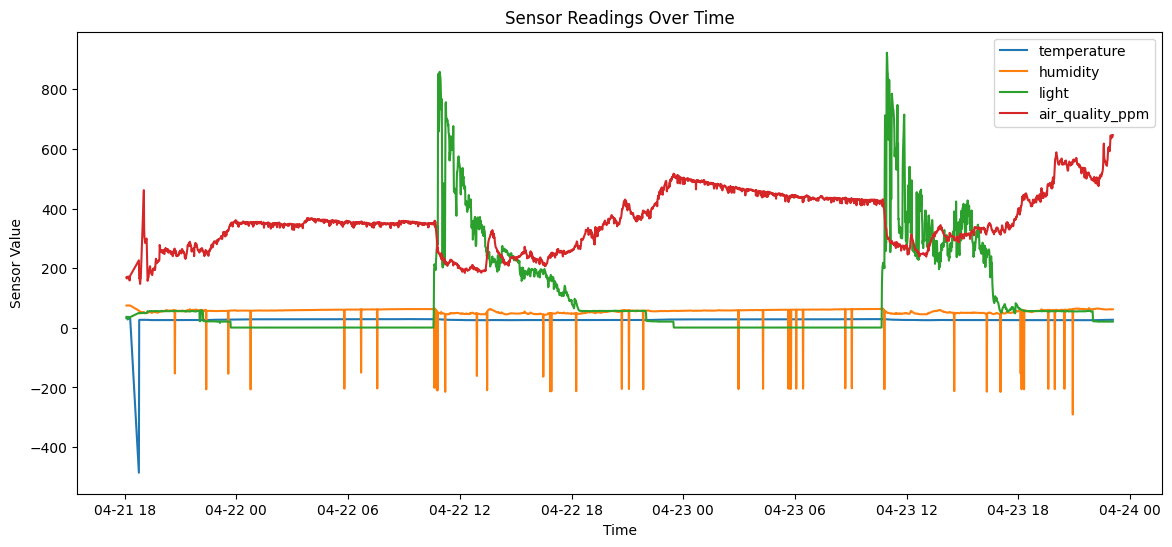

In [27]:
import matplotlib.pyplot as plt

# Plot all 4 sensors over time
plt.figure(figsize=(14,6))

for col in ['temperature', 'humidity', 'light', 'air_quality_ppm']:
    plt.plot(df_resampled.index, df_resampled[col], label=col)

plt.title("Sensor Readings Over Time")
plt.xlabel("Time")
plt.ylabel("Sensor Value")
plt.legend()
plt.show()

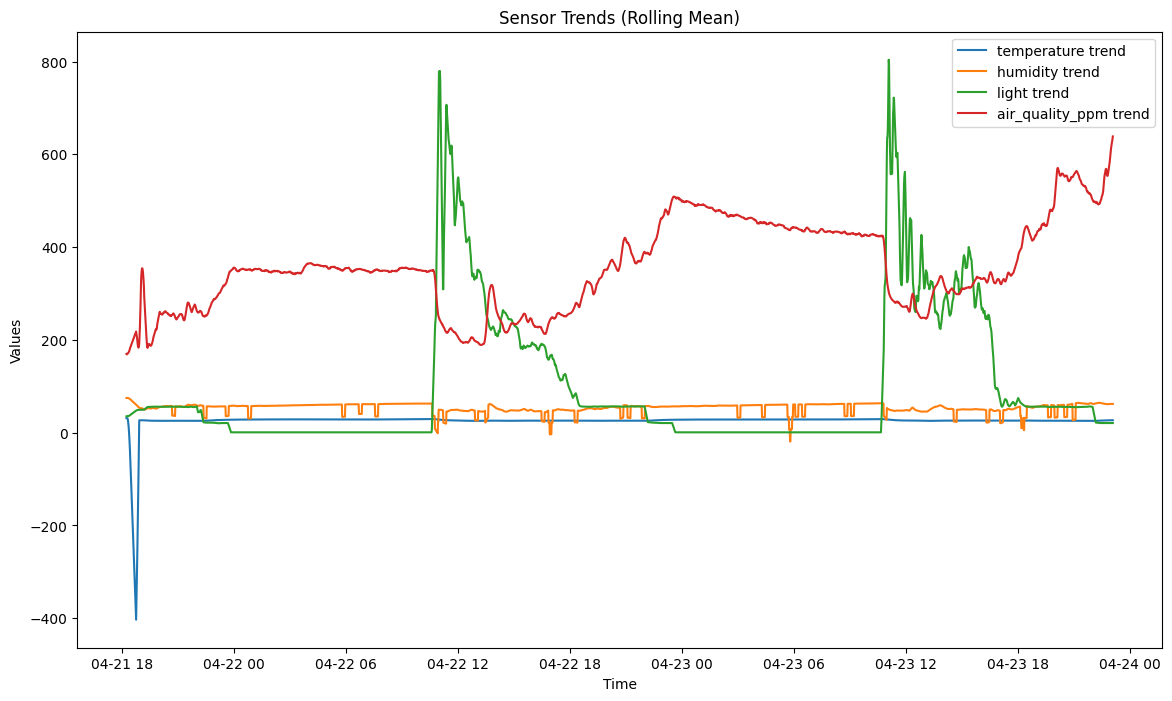

In [28]:
# Step 8: Rolling trend analysis for all sensors

import matplotlib.pyplot as plt

sensor_cols = ['temperature', 'humidity', 'light', 'air_quality_ppm']

plt.figure(figsize=(14,8))

for col in sensor_cols:
    plt.plot(df_resampled.index, df_resampled[col].rolling(window=10).mean(), label=f"{col} trend")

plt.title("Sensor Trends (Rolling Mean)")
plt.xlabel("Time")
plt.ylabel("Values")
plt.legend()
plt.show()

**Anomaly Detection**

In [29]:
from sklearn.ensemble import IsolationForest

# Select sensor data
sensor_cols = ['temperature', 'humidity', 'light', 'air_quality_ppm']

X = df_resampled[sensor_cols]

print(X.head())

                     temperature   humidity      light  air_quality_ppm
timestamp                                                              
2026-04-21 18:06:00    32.093750  74.550000  36.666660       169.069150
2026-04-21 18:07:00    31.812500  74.700000  36.666660       165.161400
2026-04-21 18:08:00    31.458333  74.833333  36.666660       170.085667
2026-04-21 18:09:00    31.359375  74.875000  36.666660       171.054000
2026-04-21 18:10:00    31.296875  74.875000  27.916662       170.163325


In [30]:
# Train Isolation Forest model

model = IsolationForest(contamination=0.05, random_state=42)

df_resampled['anomaly'] = model.fit_predict(X)

# Check results
df_resampled['anomaly'].value_counts()

,count
anomaly,
1,3020
-1,159


In [31]:
# Show some anomaly rows
anomalies = df_resampled[df_resampled['anomaly'] == -1]

display(anomalies.head())

,temperature,humidity,light,air_quality_ppm,air_quality_diff,temperature_smooth,humidity_smooth,light_smooth,air_quality_diff_smooth,anomaly
timestamp,,,,,,,,,,
2026-04-21 18:06:00,32.093750,74.550000,36.666660,169.069150,-3.949050,31.031250,74.585000,109.666677,-1.324540,-1
2026-04-21 18:07:00,31.812500,74.700000,36.666660,165.161400,-3.907750,31.508333,74.541667,112.416677,-1.260922,-1
2026-04-21 18:08:00,31.458333,74.833333,36.666660,170.085667,4.924267,31.916667,74.621667,110.750011,0.569100,-1
2026-04-21 18:09:00,31.359375,74.875000,36.666660,171.054000,0.968333,32.082292,74.691667,36.666660,-0.217505,-1
2026-04-21 18:10:00,31.296875,74.875000,27.916662,170.163325,-0.890675,31.604167,74.766667,34.916660,-0.570975,-1


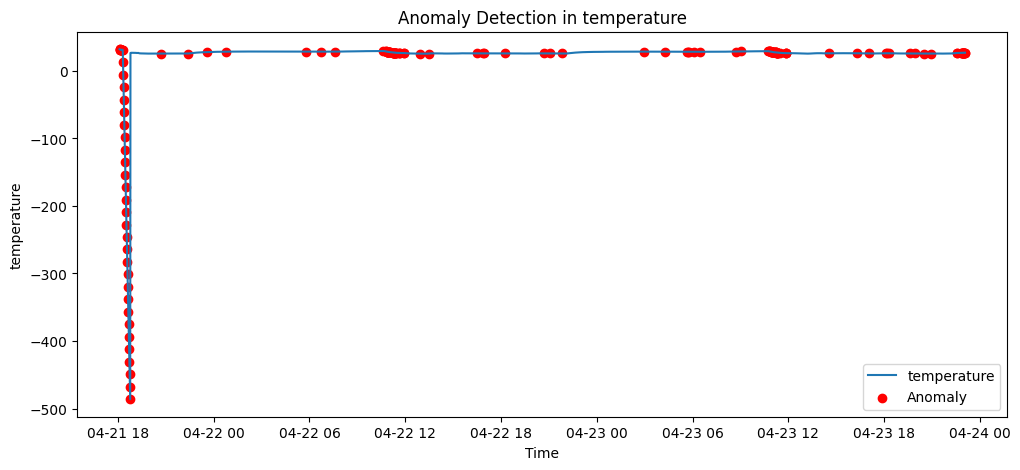

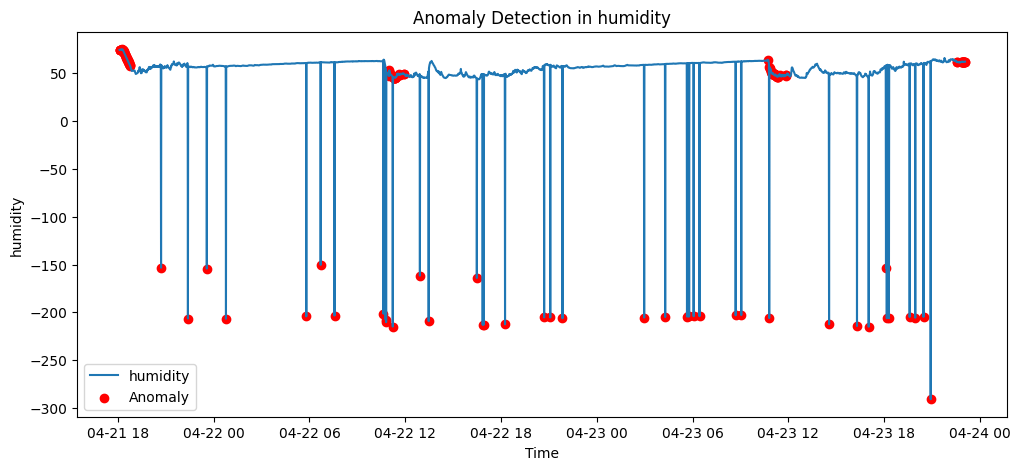

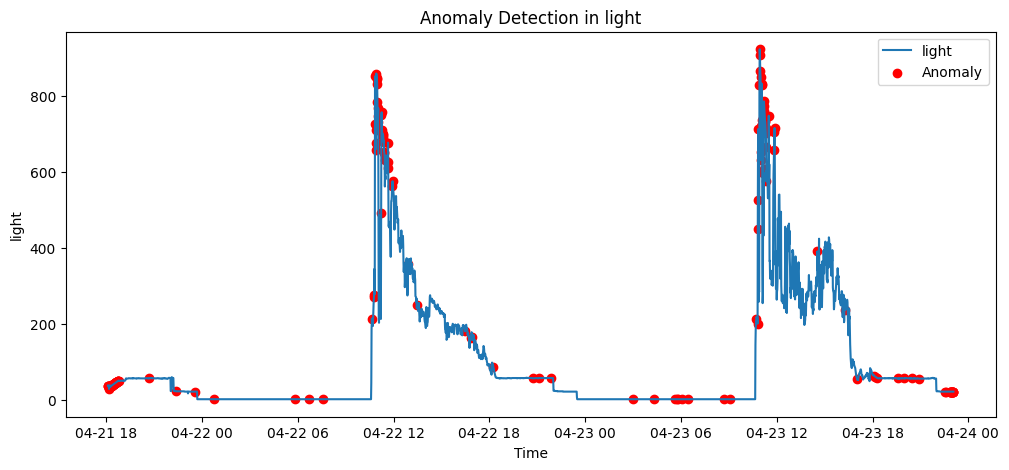

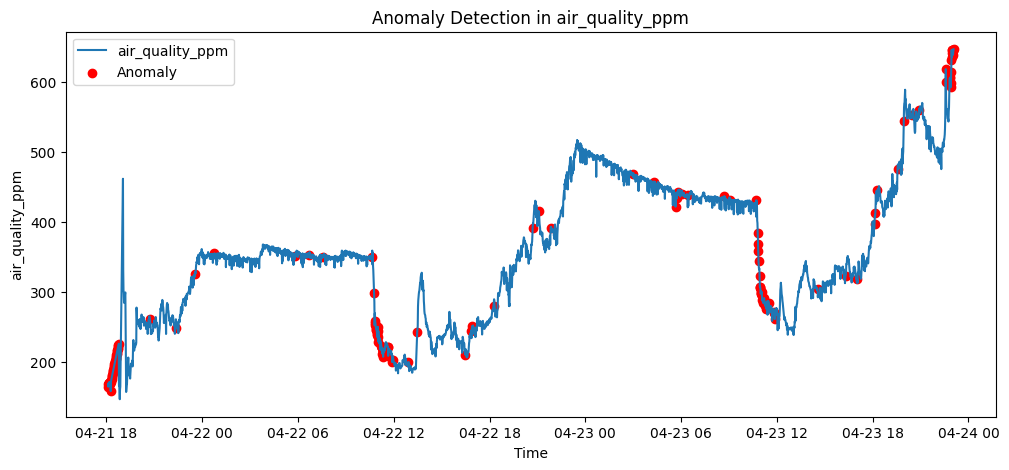

In [33]:
import matplotlib.pyplot as plt

sensor_cols = ['temperature', 'humidity', 'light', 'air_quality_ppm']

for col in sensor_cols:
    plt.figure(figsize=(12,5))

    # Plot normal data
    plt.plot(df_resampled.index, df_resampled[col], label=col)

    # Plot anomalies
    anomalies = df_resampled[df_resampled['anomaly'] == -1]

    plt.scatter(anomalies.index, anomalies[col],
                color='red', label='Anomaly')

    plt.title(f"Anomaly Detection in {col}")
    plt.xlabel("Time")
    plt.ylabel(col)
    plt.legend()
    plt.show()

**Correation and Feature Importance**

In [34]:
from sklearn.ensemble import RandomForestRegressor

# Features (inputs)
X = df_resampled[['humidity', 'light', 'air_quality_ppm']]

# Target (output)
y = df_resampled['temperature']

In [35]:
model = RandomForestRegressor(random_state=42)

model.fit(X, y)

RandomForestRegressor(random_state=42)

In [36]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)

print(importance.sort_values(ascending=False))

humidity           0.715530
air_quality_ppm    0.151235
light              0.133235
dtype: float64


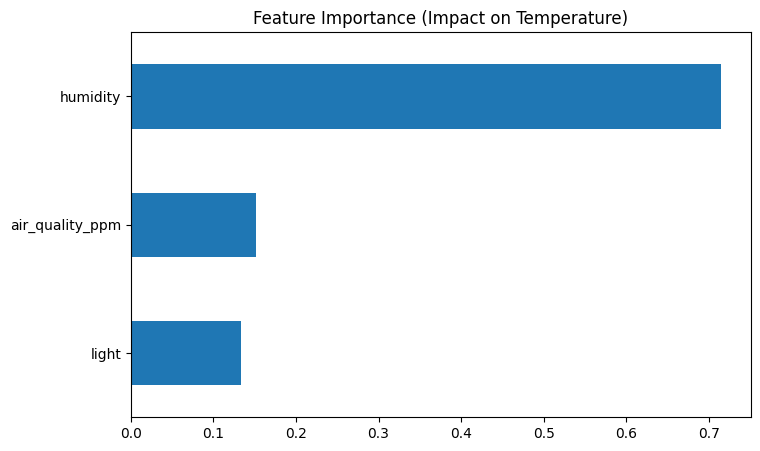

In [37]:
importance.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance (Impact on Temperature)")
plt.show()

In [38]:
# Second correlation: Predict humidity

X2 = df_resampled[['temperature', 'light', 'air_quality_ppm']]
y2 = df_resampled['humidity']

from sklearn.ensemble import RandomForestRegressor

model2 = RandomForestRegressor(random_state=42)
model2.fit(X2, y2)

# Feature importance
importance2 = pd.Series(model2.feature_importances_, index=X2.columns)

print(importance2.sort_values(ascending=False))

air_quality_ppm    0.555679
temperature        0.254556
light              0.189765
dtype: float64


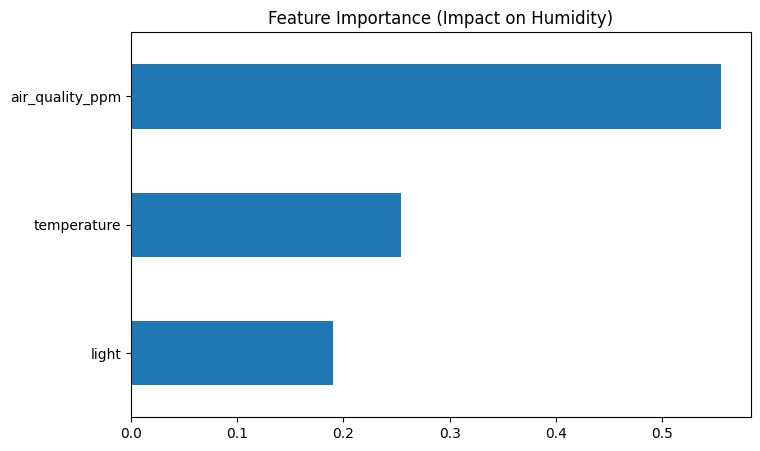

In [39]:
importance2.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance (Impact on Humidity)")
plt.show()

In [40]:
# Third correlation: Predict air quality

X3 = df_resampled[['temperature', 'humidity', 'light']]
y3 = df_resampled['air_quality_ppm']

from sklearn.ensemble import RandomForestRegressor

model3 = RandomForestRegressor(random_state=42)
model3.fit(X3, y3)

# Feature importance
importance3 = pd.Series(model3.feature_importances_, index=X3.columns)

print(importance3.sort_values(ascending=False))

humidity       0.628924
temperature    0.273487
light          0.097589
dtype: float64


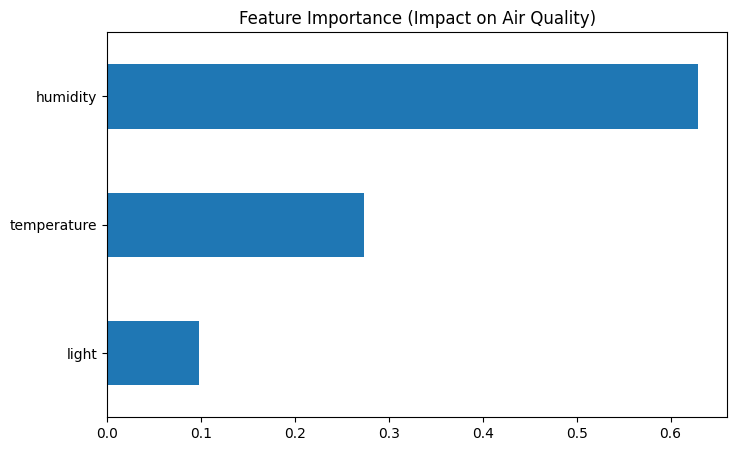

In [41]:
importance3.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance (Impact on Air Quality)")
plt.show()